# Language Detection Using Recurrent Neural Networks

**Nizar Elouarti | AI 574 | Assignment 1**

Given a sentence, predict one of the ten Tatoeba language codes. This is multiclass sentence classification. Unlike a word-based sentiment model, this detector reads **characters**: spelling, accents, and character order provide useful language cues, including for unfamiliar words.

We use a character embedding followed by a bidirectional GRU (a gated recurrent neural network) and a linear classifier. The two final recurrent states summarize the sentence; cross-entropy trains the classifier on raw logits.

## Data and Experimental Design

The supplied training file actually has **100,000** sentences (10,000 per language); the development file has **10,000** (1,000 per language). To match the requested experiment, we select a seeded, stratified **10,000-sentence training subset**, and retain the complete development file for validation. Exact normalized train/validation duplicates are excluded from the training pool. Set `TRAIN_SIZE = None` to use the entire eligible training pool.

Character vocabulary and class mappings are fitted on training data only. Validation selects the best epoch; it is **not an independent test set**. Results below are measured by running the notebook, not assumed.

In [20]:
from pathlib import Path
import random
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, f1_score
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_sequence
from torch.utils.data import DataLoader

SEED = 42
TRAIN_SIZE = 10_000
MAX_LENGTH = 160
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 0.003

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.set_num_threads(min(4, torch.get_num_threads()))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

candidate_roots = [Path.cwd(), *Path.cwd().parents]
assignment_dir = next(
    (candidate for root in candidate_roots
     for candidate in (root, root / 'AI 574' / 'Assignment_1')
     if (candidate / 'Data' / 'tatoeba' / 'sentences.top10langs.train.tsv').is_file()),
    None,
 )
if assignment_dir is None:
    raise FileNotFoundError('Run from the repository or assignment directory containing Data/tatoeba.')
data_dir = assignment_dir / 'Data' / 'tatoeba'


def normalize_text(text):
    return unicodedata.normalize('NFC', text).strip().lower()


def load_sentences(path):
    frame = pd.read_csv(path, sep='\t', header=None, names=['language', 'text'],
                        quoting=3, keep_default_na=False, encoding='utf-8')
    if frame.empty or not frame['language'].str.fullmatch(r'[a-z]{3}').all():
        raise ValueError(f'Invalid language codes in {path.name}')
    frame['text'] = frame['text'].map(normalize_text)
    if frame['text'].eq('').any():
        raise ValueError(f'Empty sentences in {path.name}')
    return frame


train_pool = load_sentences(data_dir / 'sentences.top10langs.train.tsv')
val_frame = load_sentences(data_dir / 'sentences.top10langs.dev.tsv')
original_train_count = len(train_pool)
train_pool = train_pool.loc[~train_pool['text'].isin(set(val_frame['text']))].copy()
removed_overlap = original_train_count - len(train_pool)
languages = sorted(train_pool['language'].unique())
assert len(languages) == 10
assert set(val_frame['language']) == set(languages)
if TRAIN_SIZE is None:
    train_frame = train_pool.reset_index(drop=True)
else:
    if TRAIN_SIZE <= 0 or TRAIN_SIZE % len(languages):
        raise ValueError('TRAIN_SIZE must be positive and divisible by the number of languages.')
    per_language = TRAIN_SIZE // len(languages)
    train_frame = pd.concat([
        train_pool.loc[train_pool['language'].eq(language)].sample(per_language, random_state=SEED)
        for language in languages
    ], ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

language_names = {
    'ber': 'Berber', 'deu': 'German', 'eng': 'English', 'epo': 'Esperanto',
    'fra': 'French', 'hun': 'Hungarian', 'ita': 'Italian', 'por': 'Portuguese',
    'spa': 'Spanish', 'tur': 'Turkish',
}
label_to_id = {language: index for index, language in enumerate(languages)}
PAD_ID, UNK_ID = 0, 1
characters = sorted(set(''.join(train_frame['text'])))
char_to_id = {'<PAD>': PAD_ID, '<UNK>': UNK_ID}
char_to_id.update({character: index + 2 for index, character in enumerate(characters)})

print(f'Device: {device}; original training rows: {original_train_count:,}')
print(f'Train/validation overlap rows removed: {removed_overlap:,}')
print(f'Training: {len(train_frame):,}; validation: {len(val_frame):,}; vocabulary: {len(char_to_id)}')
print(f'Training sentences truncated at {MAX_LENGTH} characters: {(train_frame.text.str.len() > MAX_LENGTH).mean():.1%}')
display(pd.DataFrame({'train': train_frame.language.value_counts(),
                      'validation': val_frame.language.value_counts()}).sort_index())

Device: cpu; original training rows: 100,000
Train/validation overlap rows removed: 0
Training: 10,000; validation: 10,000; vocabulary: 125
Training sentences truncated at 160 characters: 0.4%


,train,validation
language,,
ber,1000,1000
deu,1000,1000
eng,1000,1000
epo,1000,1000
fra,1000,1000
hun,1000,1000
ita,1000,1000
por,1000,1000
spa,1000,1000


## Character Encoding and Recurrent Classifier

Normalize Unicode to NFC and lowercase while preserving accents and punctuation. Each character becomes a training-vocabulary ID; unseen characters use `<UNK>`. Sentences are truncated to 160 characters, padded within each batch, and **packed using their actual lengths** so padding never enters the recurrent state.

The network is `Embedding(32) -> bidirectional GRU(64) -> Dropout(0.2) -> Linear(10)`. It produces one score per language. No softmax is used before cross-entropy; softmax is used only to display prediction probabilities.

In [25]:
def encode_text(text, vocabulary=None, max_length=MAX_LENGTH):
    if not isinstance(text, str) or not isinstance(max_length, int) or isinstance(max_length, bool) or max_length <= 0:
        raise ValueError('Provide a string and a positive integer max_length.')
    text = normalize_text(text)
    if not text:
        raise ValueError('Provide a non-empty sentence.')
    vocabulary = char_to_id if vocabulary is None else vocabulary
    return torch.tensor([vocabulary.get(character, UNK_ID) for character in text[:max_length]],
                        dtype=torch.long)


def expect_value_error(function, *args, **kwargs):
    try:
        function(*args, **kwargs)
    except ValueError:
        return
    raise AssertionError(f'{function.__name__} must reject invalid input.')


def make_dataset(frame):
    return [(encode_text(text), label_to_id[language])
            for language, text in frame.itertuples(index=False, name=None)]


def collate_sentences(batch):
    sequences, targets = zip(*batch)
    lengths = torch.tensor([len(sequence) for sequence in sequences], dtype=torch.long)
    return (pad_sequence(sequences, batch_first=True, padding_value=PAD_ID),
            lengths, torch.tensor(targets, dtype=torch.long))


train_dataset, val_dataset = make_dataset(train_frame), make_dataset(val_frame)
shuffle_generator = torch.Generator().manual_seed(SEED)
loader_options = dict(batch_size=BATCH_SIZE, collate_fn=collate_sentences, num_workers=0)
train_loader = DataLoader(train_dataset, shuffle=True, generator=shuffle_generator, **loader_options)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_options)


class LanguageRNN(nn.Module):
    def __init__(self, vocab_size, num_classes, embedding_dim=32, hidden_size=64, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=PAD_ID)
        self.rnn = nn.GRU(embedding_dim, hidden_size, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, character_ids, lengths):
        packed = pack_padded_sequence(self.embedding(character_ids), lengths.cpu(),
                                      batch_first=True, enforce_sorted=False)
        _, hidden = self.rnn(packed)
        return self.classifier(self.dropout(torch.cat((hidden[-2], hidden[-1]), dim=1)))


model_config = dict(vocab_size=len(char_to_id), num_classes=len(languages),
                    embedding_dim=32, hidden_size=64, dropout=0.2)
criterion = nn.CrossEntropyLoss()
assert len(train_dataset) == len(train_frame) and len(val_dataset) == len(val_frame)
assert torch.equal(train_dataset[0][0], encode_text(train_frame.iloc[0]['text']))
expect_value_error(encode_text, 'Hello', max_length=0)
expect_value_error(encode_text, 'Hello', max_length=-1)
expect_value_error(encode_text, 123)
print(f'Encoded {len(train_dataset):,} training and {len(val_dataset):,} validation sentences; input guards passed.')

Encoded 10,000 training and 10,000 validation sentences; input guards passed.


## Training and Model Selection

`run_epoch` handles training and evaluation, optionally collecting predictions for the classification report. Adam, cross-entropy, gradient clipping at 1.0, early stopping after three non-improving epochs, and lowest-validation-loss selection are retained. The balanced random-guess baseline is **10%**. Evaluation uses inference mode; loss and accuracy totals remain on the model device until the end of the epoch.

Training replaces each non-padding character with `<UNK>` with probability **0.1**, allowing the unknown-character embedding used by SHAP/LIME to learn. Validation and prediction are never randomly masked; padding is never replaced. Set `mask_probability=0` to disable this augmentation. Training on some masked characters does not make an entirely masked sentence a neutral baseline or guarantee faithful explanations.

The next cell defines `train_model`; the following one starts full training. **Every call starts fresh**: model weights, optimizer, Torch seed, and the shuffle generator are reset together. It does not resume training from an existing model. During this optimization pass, only two one-epoch, 32-example CPU smoke runs were executed. They verified reproducibility and that the UNK embedding learns; they are not accuracy experiments. The original full-data checkpoint and its **96.25%** validation accuracy were preserved. It was trained without masking. Running all cells trains a fresh masked model and recomputes the results; full-data masked-model accuracy remains unmeasured.

In [24]:
import time


def mask_training_characters(character_ids, probability):
    if not 0 <= probability <= 1:
        raise ValueError('Character masking probability must be between 0 and 1.')
    if probability == 0:
        return character_ids
    selected = (torch.rand(character_ids.shape, device=character_ids.device) < probability)
    return character_ids.masked_fill(selected & character_ids.ne(PAD_ID), UNK_ID)


def run_epoch(network, loader, optimizer=None, collect=False):
    training = optimizer is not None
    network.train(training)
    actual, predicted, total_examples = [], [], 0
    network_device = next(network.parameters()).device
    totals = torch.zeros(2, dtype=torch.float64, device=network_device)
    with (torch.enable_grad() if training else torch.inference_mode()):
        for character_ids, lengths, targets in loader:
            character_ids, targets = character_ids.to(network_device), targets.to(network_device)
            if training:
                optimizer.zero_grad(set_to_none=True)
                character_ids = mask_training_characters(
                    character_ids, getattr(network, 'character_mask_probability', 0.0),
                )
            logits = network(character_ids, lengths)
            loss = criterion(logits, targets)
            if not torch.isfinite(loss):
                raise RuntimeError('Non-finite training or validation loss.')
            if training:
                loss.backward()
                nn.utils.clip_grad_norm_(network.parameters(), max_norm=1.0)
                optimizer.step()
            guesses = logits.argmax(dim=1)
            total_examples += targets.size(0)
            totals[0].add_(loss.detach().double(), alpha=targets.size(0))
            totals[1].add_((guesses == targets).sum())
            if collect:
                actual.extend(targets.cpu().tolist())
                predicted.extend(guesses.cpu().tolist())
    if not total_examples:
        raise ValueError('The data loader must contain examples.')
    loss, accuracy = (totals / total_examples).tolist()
    return loss, accuracy, actual, predicted


def train_model(epochs=EPOCHS, patience=3, train_batches=None, val_batches=None,
                mask_probability=0.1, training_device=None):
    if epochs < 1 or patience < 1 or not 0 <= mask_probability <= 1:
        raise ValueError('Use positive epochs/patience and a masking probability in [0, 1].')
    torch.manual_seed(SEED)
    shuffle_generator.manual_seed(SEED)
    network = LanguageRNN(**model_config).to(device if training_device is None else training_device)
    network.character_mask_probability = mask_probability
    optimizer = torch.optim.Adam(network.parameters(), lr=LEARNING_RATE)
    train_batches = train_loader if train_batches is None else train_batches
    val_batches = val_loader if val_batches is None else val_batches
    history, best_state, best_epoch, stale_epochs = [], None, 0, 0
    best_loss = float('inf')
    for epoch in range(1, epochs + 1):
        start = time.perf_counter()
        train_loss, train_accuracy, _, _ = run_epoch(network, train_batches, optimizer)
        val_loss, val_accuracy, _, _ = run_epoch(network, val_batches)
        history.append(dict(epoch=epoch, train_loss=train_loss, val_loss=val_loss,
                            train_accuracy=train_accuracy, val_accuracy=val_accuracy))
        print(f'Epoch {epoch:02d}: train {train_loss:.4f}/{train_accuracy:.2%} | '
              f'validation {val_loss:.4f}/{val_accuracy:.2%} | {time.perf_counter() - start:.1f}s', flush=True)
        if val_loss < best_loss:
            best_loss, best_epoch, stale_epochs = val_loss, epoch, 0
            best_state = {name: value.detach().cpu().clone() for name, value in network.state_dict().items()}
        else:
            stale_epochs += 1
            if stale_epochs >= patience:
                print('Early stopping: validation loss stopped improving.')
                break
    network.load_state_dict(best_state)
    network.eval()
    print(f'Restored best model from epoch {best_epoch}.')
    return network, pd.DataFrame(history), best_epoch, best_loss


mask_probe = torch.tensor([[2, 3, PAD_ID]])
assert torch.equal(mask_training_characters(mask_probe, 0), mask_probe)
assert mask_training_characters(mask_probe, 1).tolist() == [[UNK_ID, UNK_ID, PAD_ID]]
print('Training-mask checks passed: probability endpoints and unchanged padding.')

Training-mask checks passed: probability endpoints and unchanged padding.


In [ ]:
model, history_frame, best_epoch, best_val_loss = train_model()

## Validation and Error Analysis

Evaluate the selected checkpoint on all 10,000 validation sentences using the same epoch function as training. Per-language precision, recall, F1, the row-normalized confusion matrix, and misclassified examples complement overall accuracy.

The preserved checkpoint has **96.25% validation accuracy**, **0.9625 macro F1**, and **0.1202 cross-entropy loss**, unchanged by the refactor. Portuguese recall is 91.0% and Spanish recall is 92.9%. Its recorded training history shows decreasing training loss but fluctuating validation loss, consistent with overfitting. Epoch 3 had the lowest validation loss, although epoch 4 had slightly higher accuracy.

These are validation results, not independent test performance. The preserved checkpoint came from the earlier continued training run. The refactored training command always initializes a fresh model; running it will replace the in-memory model, and running the later saving cell will replace the checkpoint. Fresh-run metrics may differ from the recorded results above.

Best epoch: 3; validation loss: 0.1202
Validation accuracy: 96.25%; macro F1: 0.9625
                  precision    recall  f1-score   support

    ber (Berber)      0.982     0.981     0.981      1000
    deu (German)      0.983     0.962     0.972      1000
   eng (English)      0.967     0.961     0.964      1000
 epo (Esperanto)      0.973     0.983     0.978      1000
    fra (French)      0.964     0.963     0.963      1000
 hun (Hungarian)      0.982     0.981     0.981      1000
   ita (Italian)      0.919     0.975     0.946      1000
por (Portuguese)      0.957     0.910     0.933      1000
   spa (Spanish)      0.919     0.929     0.924      1000
   tur (Turkish)      0.983     0.980     0.981      1000

        accuracy                          0.963     10000
       macro avg      0.963     0.963     0.963     10000
    weighted avg      0.963     0.963     0.963     10000



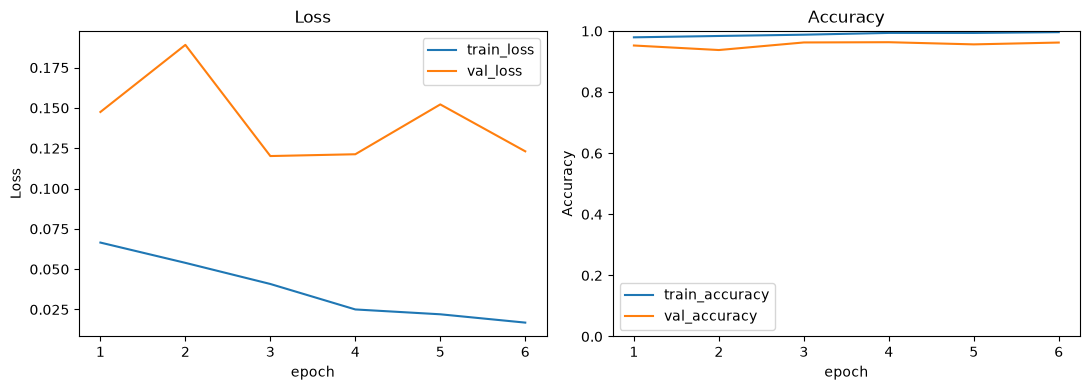

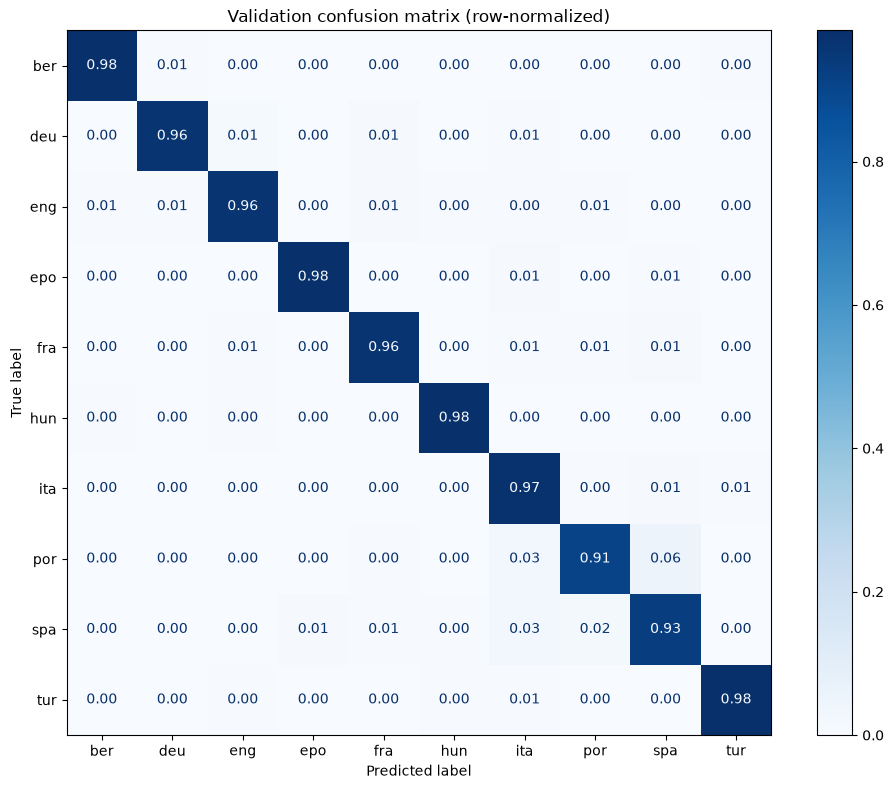

,language,text,predicted
1,por,"na semana que vem, tudo será diferente.",spa
2,por,tu deverias realmente beber menos café.,spa
13,por,abra as malas.,spa
19,por,a noite estava fria.,ita
27,por,"tentando passar de uma língua para outra, a ge...",spa
31,por,dirijo muito rápido.,spa
39,por,estás preparado para o pior?,spa
44,por,"sim, claro que concordo.",spa
55,por,esta cadeira de madeira custa sessenta libras.,spa
58,por,as eleições presidenciais foram influenciadas ...,spa


In [30]:
validation_loss, validation_accuracy, validation_targets, validation_predictions = run_epoch(
    model, val_loader, collect=True,
 )
validation_macro_f1 = f1_score(validation_targets, validation_predictions, average='macro')
assert np.isclose(validation_loss, best_val_loss, atol=1e-6)
print(f'Best epoch: {best_epoch}; validation loss: {validation_loss:.4f}')
print(f'Validation accuracy: {validation_accuracy:.2%}; macro F1: {validation_macro_f1:.4f}')
print(classification_report(
    validation_targets, validation_predictions, labels=list(range(len(languages))),
    target_names=[f'{code} ({language_names.get(code, code)})' for code in languages],
    digits=3, zero_division=0,
))

figure, axes = plt.subplots(1, 2, figsize=(11, 4))
for axis, metric in zip(axes, ['loss', 'accuracy']):
    history_frame.plot(x='epoch', y=[f'train_{metric}', f'val_{metric}'], ax=axis)
    axis.set(title=metric.title(), ylabel=metric.title())
axes[1].set_ylim(0, 1)
figure.tight_layout()
plt.show()

ConfusionMatrixDisplay.from_predictions(
    validation_targets, validation_predictions, labels=list(range(len(languages))),
    display_labels=languages, normalize='true', cmap='Blues', values_format='.2f',
    ax=plt.subplots(figsize=(10, 8))[1],
 )
plt.title('Validation confusion matrix (row-normalized)')
plt.tight_layout()
plt.show()

predicted_codes = np.array(languages)[validation_predictions]
errors = val_frame.assign(predicted=predicted_codes).loc[val_frame.language != predicted_codes]
display(errors.head(10))

## Prediction and Explicit Checkpoint Saving

`predict_language` returns ranked language probabilities through the shared batched inference path. Input lengths must be positive integers, and language codes must be unique with one code per classifier output.

Prediction cells **do not save or overwrite checkpoints**. After full training and validation, explicitly run `save_language_model(assignment_dir / 'language_rnn_masked.pt')` to save the selected weights, architecture, vocabulary, language order, normalization, maximum length, masking probability, history, and validation metrics. Saving refuses to overwrite an existing path unless `overwrite=True` is explicitly passed.

Reload with `loaded_model, checkpoint = load_language_model(assignment_dir / 'language_rnn_masked.pt')`, then call `predict_language('Hello world!', predictor=loaded_model)`. Saved preprocessing and language ordering are attached to the loaded model; no manual metadata arguments are needed. Legacy checkpoints without masking metadata default to probability zero. The diagnostic cell uses a temporary file to verify round-trip probabilities, rankings, and overwrite protection without modifying the original checkpoint.

In [26]:
def batch_probabilities(character_ids, lengths, predictor=None):
    predictor = model if predictor is None else predictor
    predictor.eval()
    with torch.inference_mode():
        logits = predictor(character_ids.to(next(predictor.parameters()).device), lengths)
        return logits.softmax(dim=1).cpu().numpy()


def predict_proba(texts, predictor=None, vocabulary=None, max_length=None):
    predictor = model if predictor is None else predictor
    vocabulary = getattr(predictor, 'vocabulary', char_to_id) if vocabulary is None else vocabulary
    max_length = getattr(predictor, 'max_length', MAX_LENGTH) if max_length is None else max_length
    if not isinstance(max_length, int) or isinstance(max_length, bool) or max_length <= 0:
        raise ValueError('max_length must be a positive integer.')
    if len(vocabulary) != predictor.embedding.num_embeddings:
        raise ValueError('Vocabulary size must match the model embedding.')
    texts = [texts] if isinstance(texts, str) else list(texts)
    if not texts:
        return np.empty((0, predictor.classifier.out_features), dtype=np.float32)
    probabilities = []
    for start in range(0, len(texts), BATCH_SIZE):
        batch = [(encode_text(text, vocabulary, max_length), 0) for text in texts[start:start + BATCH_SIZE]]
        character_ids, lengths, _ = collate_sentences(batch)
        probabilities.append(batch_probabilities(character_ids, lengths, predictor))
    return np.concatenate(probabilities)


def predict_language(text, top_k=3, predictor=None, vocabulary=None,
                     language_codes=None, max_length=None):
    predictor = model if predictor is None else predictor
    codes = getattr(predictor, 'language_codes', languages) if language_codes is None else language_codes
    if isinstance(codes, str) or len(codes) != predictor.classifier.out_features or len(set(codes)) != len(codes):
        raise ValueError('Provide one unique language code per model output.')
    if not isinstance(top_k, int) or isinstance(top_k, bool) or not 1 <= top_k <= len(codes):
        raise ValueError('top_k must be between 1 and the number of supported languages.')
    probabilities = predict_proba(text, predictor, vocabulary, max_length)[0]
    indices = np.argsort(-probabilities)[:top_k]
    return pd.DataFrame({'code': [codes[index] for index in indices],
                         'language': [language_names.get(codes[index], codes[index]) for index in indices],
                         'probability': probabilities[indices]})


def save_language_model(path, overwrite=False):
    payload = dict(
        model_state_dict={name: value.detach().cpu() for name, value in model.state_dict().items()},
        model_config=model_config, char_to_id=char_to_id, languages=languages, max_length=MAX_LENGTH,
        normalization='NFC, strip, lowercase', seed=SEED, train_size=len(train_frame),
        best_epoch=best_epoch, best_val_loss=float(best_val_loss), history=history_frame.to_dict('records'),
        character_mask_probability=getattr(model, 'character_mask_probability', 0.0),
        validation_accuracy=float(validation_accuracy), validation_macro_f1=float(validation_macro_f1),
    )
    with Path(path).open('wb' if overwrite else 'xb') as stream:
        torch.save(payload, stream)
    print(f'Saved checkpoint: {path}')


def load_language_model(path):
    payload = torch.load(path, map_location='cpu', weights_only=True)
    predictor = LanguageRNN(**payload['model_config'])
    predictor.load_state_dict(payload['model_state_dict'])
    predictor.character_mask_probability = payload.get('character_mask_probability', 0.0)
    predictor.vocabulary, predictor.language_codes = payload['char_to_id'], payload['languages']
    predictor.max_length = payload['max_length']
    predictor.eval()
    return predictor, payload


example_sentences = {
    'eng': 'This morning I went to the library to read a book.',
    'fra': 'Bonjour, je voudrais un billet pour Paris.',
    'deu': 'Ich lese jeden Morgen die Zeitung.',
    'spa': 'Buenos dias, quiero comprar un libro.',
}
for expected_code, sentence in example_sentences.items():
    print(f'Input ({expected_code}): {sentence}')
    display(predict_language(sentence))
expect_value_error(predict_proba, 'Hello', max_length=0)
expect_value_error(predict_language, 'Hello', language_codes=['eng'], top_k=1)
expect_value_error(predict_language, 'Hello', language_codes=['eng'] * len(languages))
print('Inference guards passed. Prediction does not write or overwrite checkpoints.')

Input (eng): This morning I went to the library to read a book.


,code,language,probability
0,eng,English,0.999987
1,deu,German,0.000008
2,fra,French,0.000004


Input (fra): Bonjour, je voudrais un billet pour Paris.


,code,language,probability
0,fra,French,0.999808
1,eng,English,0.000165
2,por,Portuguese,0.000012


Input (deu): Ich lese jeden Morgen die Zeitung.


,code,language,probability
0,deu,German,0.999771
1,fra,French,0.000121
2,eng,English,0.000088


Input (spa): Buenos dias, quiero comprar un libro.


,code,language,probability
0,spa,Spanish,0.999463
1,epo,Esperanto,0.000321
2,por,Portuguese,0.000143


Inference guards passed. Prediction does not write or overwrite checkpoints.


## Interpreting the Trained RNN with SHAP and LIME

SHAP (SHapley Additive exPlanations) and LIME (Local Interpretable Model-agnostic Explanations) explain predictions by perturbing **character positions**, matching the RNN's input. Repeated letters have separate features, as do spaces and punctuation. The explainers share `predict_proba` with ordinary predictions, using identical normalization, encoding, batching, and softmax without changing model weights.

SHAP and LIME are declared in the repository's `requirements.txt`. Install dependencies once in the chosen Python/kernel environment before running the notebook, rather than reinstalling them during every run. From the repository root, use `python -m pip install -r requirements.txt`. LIME caches the same seeded perturbation probabilities across target classes while still computing each class's own surrogate and fidelity measures.

In [27]:
import shap
from lime.lime_text import LimeTextExplainer

MASK_CHARACTER = chr(0xFFFD)
assert MASK_CHARACTER not in char_to_id


def make_mask_predictor(text):
    sequence = encode_text(text, vocabulary=getattr(model, 'vocabulary', char_to_id),
                           max_length=getattr(model, 'max_length', MAX_LENGTH))

    def probabilities(masks):
        masks = np.atleast_2d(np.asarray(masks))
        if masks.ndim != 2 or masks.shape[1] != len(sequence) or np.any((masks != 0) & (masks != 1)):
            raise ValueError('Use a binary mask matrix with one column per encoded character.')
        if not len(masks):
            return np.empty((0, len(languages)), dtype=np.float32)
        character_ids = torch.where(torch.as_tensor(masks, dtype=torch.bool), sequence.unsqueeze(0), UNK_ID)
        lengths = torch.full((len(masks),), len(sequence), dtype=torch.long)
        return np.concatenate([batch_probabilities(character_ids[start:start + BATCH_SIZE],
                                                   lengths[start:start + BATCH_SIZE])
                               for start in range(0, len(masks), BATCH_SIZE)])

    return probabilities


mask_text = normalize_text('Bonjour, comment allez-vous ?')[:MAX_LENGTH]
mask_predictor = make_mask_predictor(mask_text)
probe_masks = np.vstack([np.ones(len(mask_text)), np.zeros(len(mask_text)),
                         np.random.RandomState(SEED).randint(0, 2, (8, len(mask_text)))])
reference_texts = [''.join(character if keep else MASK_CHARACTER for character, keep in zip(mask_text, mask))
                   for mask in probe_masks]
assert np.allclose(mask_predictor(probe_masks), predict_proba(reference_texts), atol=1e-6)
expect_value_error(mask_predictor, np.zeros((1, len(mask_text) + 1)))
expect_value_error(mask_predictor, np.full((1, len(mask_text)), 0.5))
print(f'SHAP {shap.__version__}; vectorized token masks match text masks, including fully masked input.')

SHAP 0.52.0; vectorized token masks match text masks, including fully masked input.


### How to Read the Explanations

**SHAP:** Kernel SHAP estimates contributions from 512 sampled character-mask coalitions. The background is one same-length sentence made entirely of unknown-character tokens, **not the average validation sentence**. An included feature keeps its character; an excluded feature replaces it with an out-of-vocabulary placeholder mapped to `<UNK>`. This preserves sequence length and position. For each class, the masked baseline plus all character contributions reconstructs the original probability; the code checks this numerically. Positive contributions support the target class relative to this baseline, and negative contributions oppose it. Waterfall plots show the largest contributions and group the remainder.

**LIME:** Character-level `LimeTextExplainer`, with `bow=False`, masks individual positions using the same placeholder. It fits a distance-weighted linear surrogate to 2,000 perturbed predictions. Its coefficients approximate how retaining each position changes the target probability within the sampled neighborhood. Positive bars support the class; negative bars oppose it. The report shows weighted R-squared, fitted value at the original sentence, and absolute error relative to the RNN. The surrogate is unconstrained, so its fitted value can fall outside [0, 1]; that is not an invalid RNN probability.

The example explains French and then the first validation error, showing both the predicted class and the true class when they differ. To explain another sentence, call `explain_language_text('Ich lese jeden Morgen die Zeitung.', true_language='deu')`. The optional `true_language` is used only to choose an additional class to explain, not fed to the model. Increase `shap_samples` and `lime_samples` to investigate sampling stability. Positions refer to normalized, truncated model input, not the original raw text.

CAUTION: this legacy model did not train its UNK embedding. Retrain with character masking.
Text: bonjour, je voudrais un billet pour paris.
Predicted: fra (99.98%); actual: fra

fra: positive contributions support this class; negative oppose it.


,position,character,SHAP,LIME
32,33,o,0.093743,0.081509
19,20,s,0.076052,0.076724
20,21,,0.071138,0.095539
5,6,u,0.070080,0.126536
14,15,u,0.068824,0.115760
11,12,,0.068494,0.081460
33,34,u,0.067319,0.101294
40,41,s,0.065119,0.023503
9,10,j,-0.061503,-0.008779
3,4,j,0.061435,0.048565


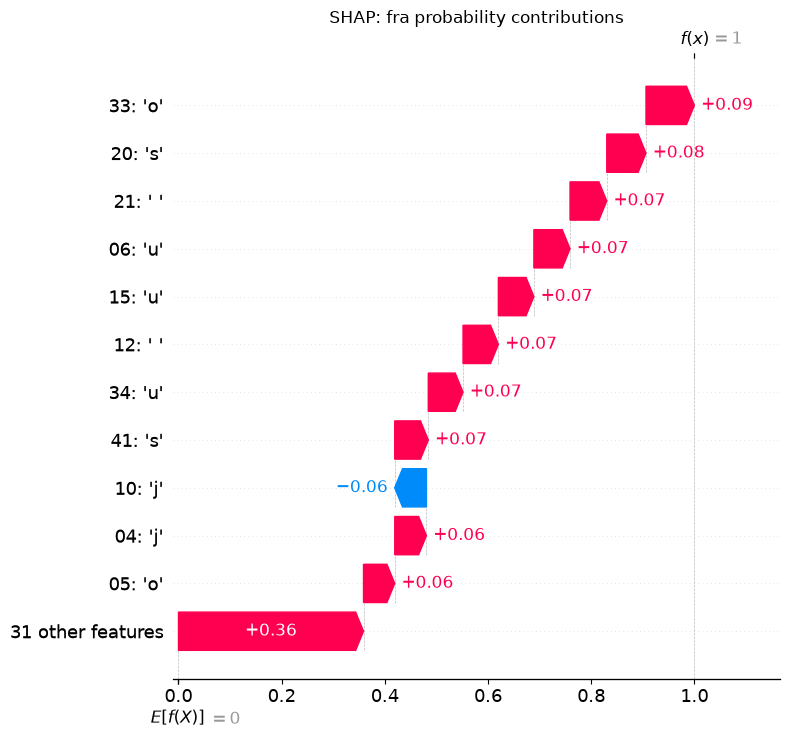

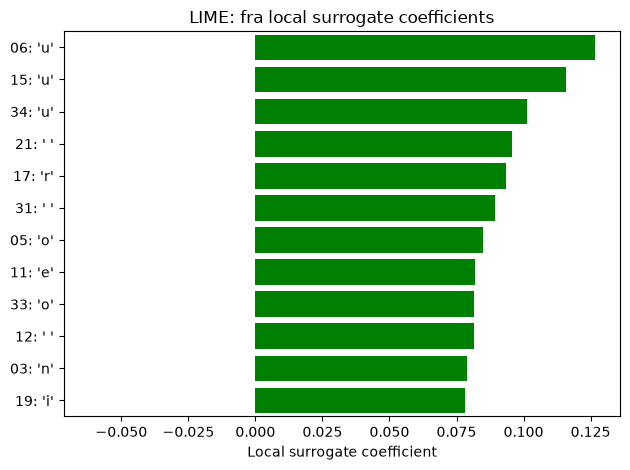

,language,model_probability,SHAP_baseline,SHAP_reconstructed,LIME_local_prediction,LIME_absolute_error,LIME_weighted_R2
0,fra,0.999808,1.576072e-08,0.999808,1.029762,0.029954,0.678894


LIME inference batches: 1 for 1 explained classes.
CAUTION: this legacy model did not train its UNK embedding. Retrain with character masking.
Text: na semana que vem, tudo será diferente.
Predicted: spa (98.21%); actual: por

spa: positive contributions support this class; negative oppose it.


,position,character,SHAP,LIME
37,38,e,0.165248,0.159439
22,23,o,0.137251,0.183931
20,21,u,0.090974,0.119948
19,20,t,-0.069281,-0.016740
23,24,,0.064130,0.080578
30,31,i,0.058995,0.071132
6,7,a,0.056241,-0.014238
27,28,á,0.054553,0.066827
33,34,r,0.053565,0.018525
28,29,,0.053051,0.085037


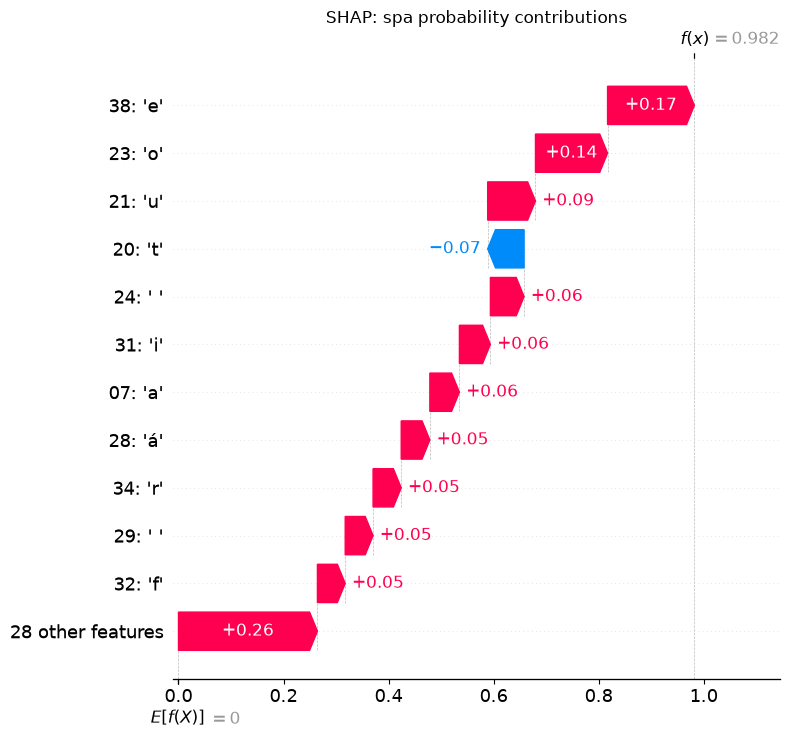

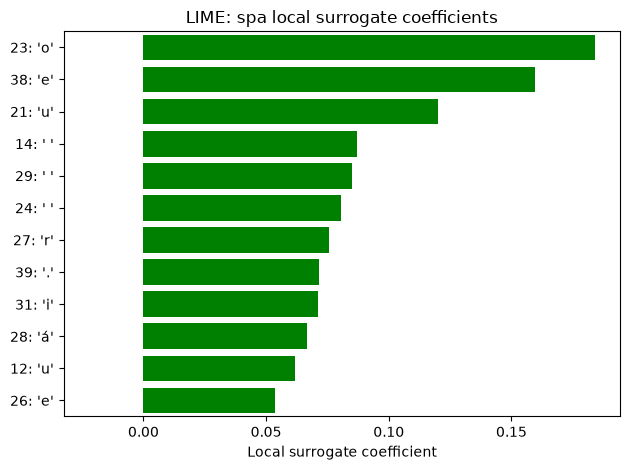


por: positive contributions support this class; negative oppose it.


,position,character,SHAP,LIME
27,28,á,-0.031257,-0.007029
28,29,,-0.030234,-0.002672
2,3,,-0.012697,-0.001458
36,37,t,0.010057,0.002078
30,31,i,-0.009508,0.001130
16,17,m,0.009211,0.001524
13,14,,-0.008906,-0.002527
22,23,o,0.008512,0.002897
10,11,q,0.008226,0.002555
32,33,e,-0.007566,0.002564


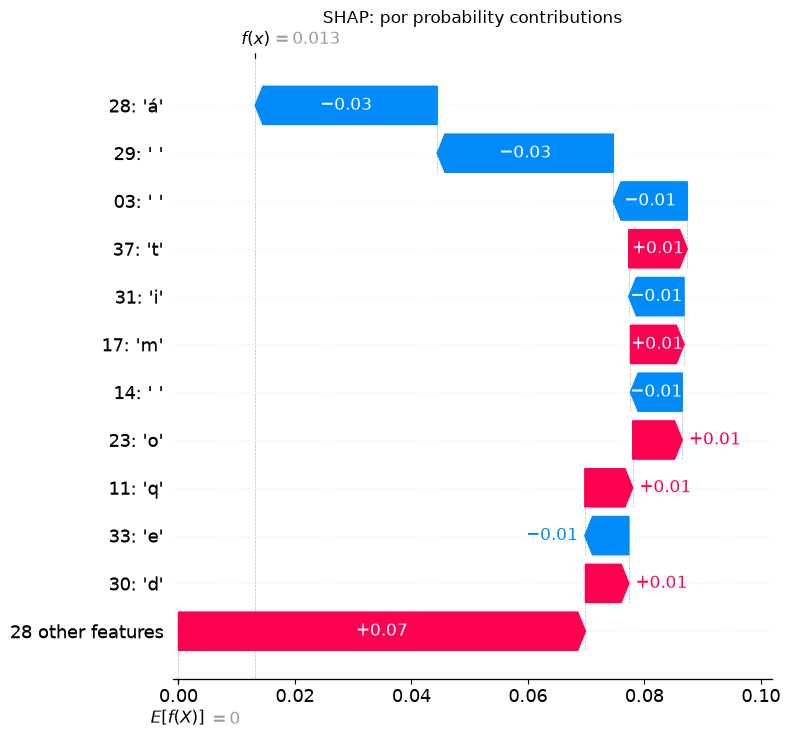

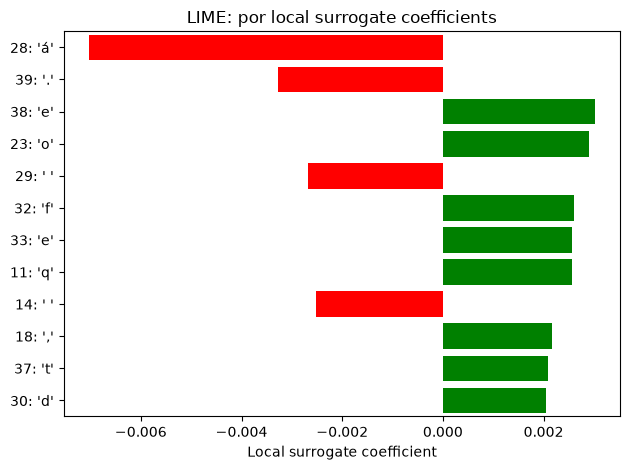

,language,model_probability,SHAP_baseline,SHAP_reconstructed,LIME_local_prediction,LIME_absolute_error,LIME_weighted_R2
0,spa,0.982110,4.950328e-08,0.982110,0.750260,0.231850,0.559525
1,por,0.013172,4.744118e-10,0.013172,0.014944,0.001772,0.085907


LIME inference batches: 1 for 2 explained classes.


In [28]:
def explain_language_text(text, true_language=None, shap_samples=512, lime_samples=2000):
    text = normalize_text(text)[:MAX_LENGTH]
    if not text:
        raise ValueError('Provide a non-empty sentence to explain.')
    if true_language is not None and true_language not in languages:
        raise ValueError('true_language must be one of the supported language codes.')
    probabilities = predict_proba(text)[0]
    predicted_index = int(probabilities.argmax())
    targets = list(dict.fromkeys([predicted_index] +
                   ([languages.index(true_language)] if true_language is not None else [])))
    feature_names = [f'{position + 1:02d}: {character!r}' for position, character in enumerate(text)]
    mask_probability = getattr(model, 'character_mask_probability', 0.0)
    if mask_probability == 0:
        print('CAUTION: this legacy model did not train its UNK embedding. Retrain with character masking.')
    mask_probabilities = make_mask_predictor(text)
    prediction_cache = {}

    def cached_probabilities(texts):
        key = tuple(texts)
        if key not in prediction_cache:
            prediction_cache[key] = predict_proba(texts)
        return prediction_cache[key]

    empty_mask, full_mask = np.zeros((1, len(text))), np.ones((1, len(text)))
    assert np.allclose(mask_probabilities(full_mask)[0], probabilities, atol=1e-6)
    kernel_explainer = shap.KernelExplainer(mask_probabilities, empty_mask, link='identity')
    previous_random_state = np.random.get_state()
    np.random.seed(SEED)
    try:
        shap_values = np.asarray(kernel_explainer.shap_values(
            full_mask, nsamples=shap_samples, l1_reg=0, silent=True,
        ))
    finally:
        np.random.set_state(previous_random_state)
    base_values = np.asarray(kernel_explainer.expected_value)
    reconstructed = base_values + shap_values[0].sum(axis=0)
    assert shap_values.shape == (1, len(text), len(languages)) and np.isfinite(shap_values).all()
    assert np.allclose(reconstructed, probabilities, atol=1e-5)

    print(f'Text: {text}\nPredicted: {languages[predicted_index]} ({probabilities[predicted_index]:.2%}); '
          f'actual: {true_language or "not supplied"}')
    reports, attribution_tables, lime_explanations = [], {}, {}
    for target in targets:
        code = languages[target]
        lime_explainer = LimeTextExplainer(
            class_names=languages, char_level=True, bow=False, mask_string=MASK_CHARACTER,
            random_state=SEED, feature_selection='none',
        )
        explanation = lime_explainer.explain_instance(
            text, cached_probabilities, labels=(target,), num_features=len(text), num_samples=lime_samples,
        )
        lime_weights = np.zeros(len(text))
        indexed_text = explanation.domain_mapper.indexed_string
        for feature_id, weight in explanation.as_map()[target]:
            lime_weights[int(indexed_text.string_position(feature_id)[0])] = weight
        local_prediction = float(np.asarray(explanation.local_pred).reshape(-1)[0])
        assert np.isfinite(lime_weights).all()
        reports.append(dict(
            language=code, model_probability=float(probabilities[target]),
            SHAP_baseline=float(base_values[target]), SHAP_reconstructed=float(reconstructed[target]),
            LIME_local_prediction=local_prediction,
            LIME_absolute_error=abs(local_prediction - float(probabilities[target])),
            LIME_weighted_R2=float(explanation.score),
        ))
        table = pd.DataFrame(dict(position=np.arange(1, len(text) + 1), character=list(text),
                                  SHAP=shap_values[0, :, target], LIME=lime_weights))
        attribution_tables[code], lime_explanations[code] = table, explanation
        print(f'\n{code}: positive contributions support this class; negative oppose it.')
        display(table.loc[table.SHAP.abs().nlargest(min(12, len(text))).index])
        shap.plots.waterfall(shap.Explanation(
            values=shap_values[0, :, target], base_values=base_values[target], feature_names=feature_names,
        ), max_display=12, show=False)
        plt.title(f'SHAP: {code} probability contributions')
        plt.tight_layout()
        plt.show()
        figure = explanation.as_pyplot_figure(label=target)
        axis = figure.axes[0]
        axis.set_yticklabels([feature_names[feature_id] for feature_id, _ in explanation.as_map()[target]][::-1])
        axis.set_ylim(max(0, len(text) - 12), len(text))
        axis.set(title=f'LIME: {code} local surrogate coefficients', xlabel='Local surrogate coefficient')
        figure.tight_layout()
        plt.show()

    report_frame = pd.DataFrame(reports)
    display(report_frame)
    print(f'LIME inference batches: {len(prediction_cache)} for {len(targets)} explained classes.')
    return dict(text=text, probabilities=probabilities, fidelity=report_frame,
                attributions=attribution_tables, lime_explanations=lime_explanations,
                lime_inference_batches=len(prediction_cache), character_mask_probability=mask_probability)


explanation_results = {'French example': explain_language_text(
    'Bonjour, je voudrais un billet pour Paris.', true_language='fra',
 )}
if not errors.empty:
    example = errors.iloc[0]
    explanation_results['Validation error'] = explain_language_text(
        example['text'], true_language=example['language'],
    )

In [29]:
from tempfile import TemporaryDirectory

for function in (encode_text, predict_language, explain_language_text):
    expect_value_error(function, '   ')
expect_value_error(explain_language_text, 'Hello!', true_language='unsupported')
expect_value_error(predict_language, 'Hello!', top_k=0)
expect_value_error(predict_language, 'Hello!', top_k=True)
expect_value_error(train_model, epochs=0)
expect_value_error(train_model, mask_probability=1.1)
expect_value_error(mask_training_characters, torch.tensor([[2, PAD_ID]]), -0.1)
assert encode_text(chr(0x1F642)).tolist() == [UNK_ID]
assert predict_proba([]).shape == (0, len(languages))
probe_ids, probe_lengths, _ = collate_sentences([(encode_text('Hello world!'), 0)])
padded_ids = nn.functional.pad(probe_ids, (0, 9), value=PAD_ID)
assert np.allclose(batch_probabilities(probe_ids, probe_lengths),
                   batch_probabilities(padded_ids, probe_lengths), atol=1e-6)
probabilities = predict_proba(list(example_sentences.values()))
assert np.isfinite(probabilities).all() and np.allclose(probabilities.sum(axis=1), 1, atol=1e-6)
assert np.allclose(probabilities, np.vstack([predict_proba(text) for text in example_sentences.values()]), atol=1e-6)

for result in explanation_results.values():
    assert result['lime_inference_batches'] == 1
    for explanation in result['lime_explanations'].values():
        indexed = explanation.domain_mapper.indexed_string
        assert indexed.inverse_removing(np.arange(indexed.num_words())) == MASK_CHARACTER * len(result['text'])
fidelity = pd.concat([result['fidelity'].assign(example=name)
                      for name, result in explanation_results.items()], ignore_index=True)
display(fidelity.assign(weak_fit=(fidelity.LIME_weighted_R2 < 0.7) | (fidelity.LIME_absolute_error > 0.05)))
print('weak_fit=True: interpret these LIME weights cautiously.')

print('CPU smoke check: two fresh one-epoch runs on 32 examples; the live model is not replaced.')
tiny_train, tiny_val = [DataLoader(dataset[:32], **loader_options) for dataset in (train_dataset, val_dataset)]
torch.manual_seed(SEED)
initial_unk = LanguageRNN(**model_config).embedding.weight[UNK_ID].detach().clone()
first_model, first_history, _, first_loss = train_model(
    1, train_batches=tiny_train, val_batches=tiny_val, training_device='cpu')
second_model, second_history, _, _ = train_model(
    1, train_batches=tiny_train, val_batches=tiny_val, training_device='cpu')
assert first_history.equals(second_history)
assert all(torch.equal(value, second_model.state_dict()[name]) for name, value in first_model.state_dict().items())
assert not torch.equal(first_model.embedding.weight[UNK_ID].detach(), initial_unk)
assert np.isclose(run_epoch(first_model, tiny_val)[0], first_loss, atol=1e-6)
first_model.character_mask_probability = 0
assert np.isclose(run_epoch(first_model, tiny_val)[0], first_loss, atol=1e-6)
first_model.character_mask_probability = 0.1
expect_value_error(run_epoch, first_model, [])

with TemporaryDirectory() as directory:
    temporary_path = Path(directory) / 'roundtrip.pt'
    save_language_model(temporary_path)
    restored_model, restored_checkpoint = load_language_model(temporary_path)
    assert np.allclose(probabilities, predict_proba(list(example_sentences.values()), predictor=restored_model), atol=1e-6)
    assert restored_model.character_mask_probability == getattr(model, 'character_mask_probability', 0.0)
    assert predict_language('Hello world!', predictor=restored_model).code.tolist() == predict_language('Hello world!').code.tolist()
    assert all(torch.equal(value.detach().cpu(), restored_checkpoint['model_state_dict'][name])
               for name, value in model.state_dict().items())
    try:
        save_language_model(temporary_path)
    except FileExistsError:
        pass
    else:
        raise AssertionError('Saving must refuse to overwrite an existing file by default.')

benchmark_masks = np.random.RandomState(SEED).randint(0, 2, (512, len(mask_text)))

def text_mask_probabilities(masks):
    return predict_proba([''.join(character if keep else MASK_CHARACTER
                                 for character, keep in zip(mask_text, mask)) for mask in masks])

assert np.allclose(mask_predictor(benchmark_masks), text_mask_probabilities(benchmark_masks), atol=1e-6)
timings = {'text': [], 'tensor': []}
for repeat in range(3):
    for name, function in [('text', text_mask_probabilities), ('tensor', mask_predictor)]:
        start = time.perf_counter()
        function(benchmark_masks)
        timings[name].append(time.perf_counter() - start)
text_time, tensor_time = np.median(timings['text']), np.median(timings['tensor'])
print(f'512 masks, median of 3 runs: text {text_time:.3f}s, tensor {tensor_time:.3f}s; ratio {text_time / tensor_time:.2f}x.')
print('Passed: input guards, padding, SHAP parity/additivity, LIME caching, CPU reproducibility, learned UNK, and checkpoint round-trip.')

,language,model_probability,SHAP_baseline,SHAP_reconstructed,LIME_local_prediction,LIME_absolute_error,LIME_weighted_R2,example,weak_fit
0,fra,0.999808,1.576072e-08,0.999808,1.029762,0.029954,0.678894,French example,True
1,spa,0.982110,4.950328e-08,0.982110,0.750260,0.231850,0.559525,Validation error,True
2,por,0.013172,4.744118e-10,0.013172,0.014944,0.001772,0.085907,Validation error,True


weak_fit=True: interpret these LIME weights cautiously.
CPU smoke check: two fresh one-epoch runs on 32 examples; the live model is not replaced.
Epoch 01: train 2.3304/3.12% | validation 2.4314/0.00% | 0.3s
Restored best model from epoch 1.
Epoch 01: train 2.3304/3.12% | validation 2.4314/0.00% | 0.2s
Restored best model from epoch 1.
Saved checkpoint: C:\Users\nizare\AppData\Local\Temp\tmpdiz34r9s\roundtrip.pt
512 masks, median of 3 runs: text 0.105s, tensor 0.088s; ratio 1.19x.
Passed: input guards, padding, SHAP parity/additivity, LIME caching, CPU reproducibility, learned UNK, and checkpoint round-trip.


### Findings from the Preserved Legacy Checkpoint

The measurements below describe the original model trained **without character masking**, not the new training configuration. Its validation accuracy remains **96.25%**, with macro F1 **0.9625**. Recompute quantitative interpretation findings after full retraining rather than carrying these values into a masked-model report.

- **Correct French prediction:** `bonjour, je voudrais un billet pour paris.` receives 99.98% French probability. SHAP and LIME both assign positive weights to the `u` positions in `bonjour`, `voudrais`, and `pour`. SHAP's largest displayed contribution is the `o` at position 33 in `pour` (about +0.094 probability units). The `j` at position 4 contributes positively, while the `j` at position 10 contributes negatively under SHAP: the same character can have different contributions depending on sequence context.
- **Portuguese mistaken for Spanish:** the first validation error receives 98.21% Spanish probability and only 1.32% Portuguese probability. Both methods attribute positive Spanish contributions to the `o` at position 23 and the final `e` at position 38. The accented `a` at position 28 supports Spanish and opposes Portuguese under both explanations. This describes the model's behavior for this particular sentence, not a correct linguistic rule about accents.
- **LIME fidelity is limited:** weighted R-squared is approximately 0.679 for French, 0.560 for the erroneous Spanish class, and 0.086 for the true Portuguese class. The Spanish surrogate fits 0.7503 at the original input versus the RNN's 0.9821, an absolute error of 0.2318. Do not regard these LIME coefficients as a faithful decomposition of the RNN. A small absolute error alone is insufficient, especially for a near-zero class probability. The diagnostic cell flags R-squared below 0.7 or error above 0.05 as heuristic warnings, not universal acceptance criteria.

### Optimization Checks

SHAP now constructs token-ID masks directly, avoiding repeated Python string reconstruction and encoding. Full, empty, and random masks matched the text route within numerical tolerance. A local CPU benchmark on 512 masks (median of three runs) measured approximately **0.105 s** for the text route and **0.088 s** for the tensor route, a **1.19x** ratio. This is a small, hardware-specific measurement, not an end-to-end speed guarantee. CPU smoke runs verified learned UNK weights and fresh-run reproducibility; GPU performance and reproducibility were not tested.

### Limitations

These are local, perturbation-based explanations, not global feature importance or causal evidence. The legacy checkpoint's UNK embedding was not learned, so explanations explicitly warn about that baseline until retraining. Masked training exposes the new model to unknown tokens but does not make highly masked sentences natural or the all-unknown baseline neutral. The chosen SHAP background strongly affects contributions. Recurrent character interactions are nonlinear, so SHAP and LIME can disagree in rankings and signs. SHAP additivity verifies reconstruction, not the accuracy or stability of its sampled individual contributions. Inspect multiple sentences and sampling seeds before generalizing, and consider masking contiguous spans or an alternative baseline as a separate sensitivity experiment. Reported legacy findings will change after retraining.